CSV loaded successfully!
Summary statistics:


,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,201.957515,116.376337,113.720571,206.643095,198.114691,26.319394,79.448857,1.146113,1.691606,0.363823,133.044668,7.172220,999.876469,0.000967,0.004806,32.504263,32.593091,NaN
std,298.495150,218.652659,158.946032,300.896893,288.889073,4.398605,20.520775,1.239248,1.617053,0.295000,114.284792,7.535093,2.104419,0.031074,0.047556,12.434899,12.009161,NaN
min,-19.500000,-7.800000,-17.900000,0.000000,0.000000,12.300000,9.900000,0.000000,0.000000,0.000000,0.000000,0.000000,993.000000,0.000000,0.000000,10.700000,11.100000,NaN
25%,-2.800000,-0.300000,-3.800000,0.000000,0.000000,23.100000,68.700000,0.000000,0.000000,0.000000,0.000000,0.000000,999.000000,0.000000,0.000000,23.500000,23.800000,NaN
50%,0.300000,-0.100000,-0.100000,3.600000,3.400000,25.300000,85.400000,0.800000,1.600000,0.400000,161.500000,6.200000,1000.000000,0.000000,0.000000,26.600000,26.900000,NaN
75%,362.400000,107.000000,224.700000,359.500000,345.400000,29.400000,96.700000,2.000000,2.600000,0.600000,234.100000,12.000000,1001.000000,0.000000,0.000000,40.900000,41.300000,NaN
max,1499.000000,946.000000,892.000000,1507.000000,1473.000000,39.900000,100.000000,19.200000,23.900000,4.100000,360.000000,98.400000,1006.000000,1.000000,2.400000,72.800000,70.400000,NaN



Missing values per column:


Comments    525600
dtype: int64

Outliers detected: 16292 rows


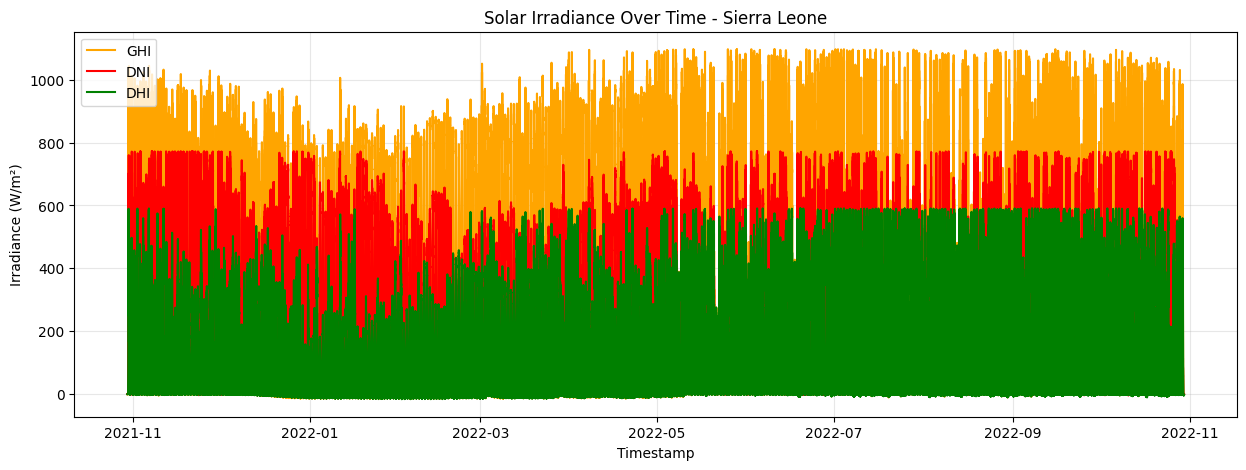

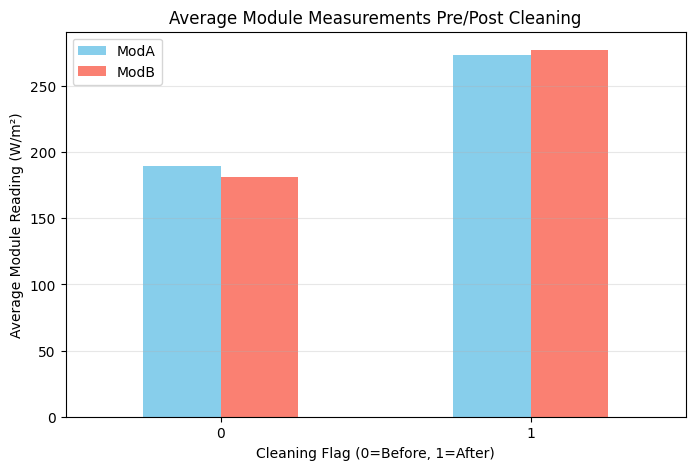

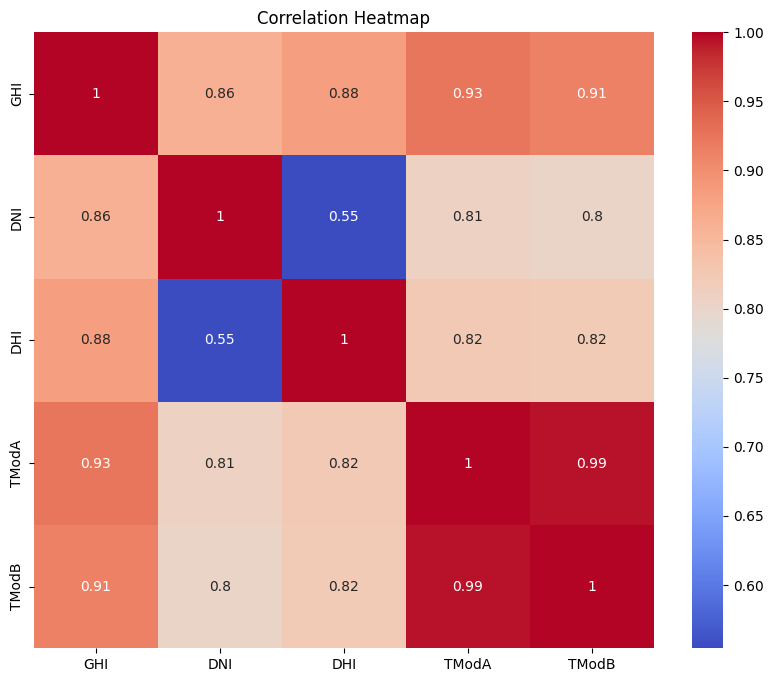

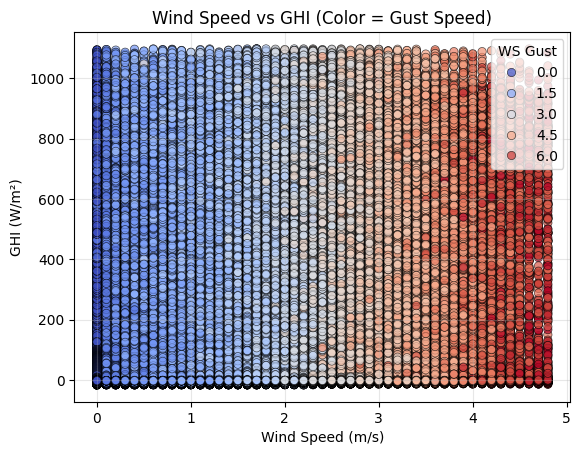

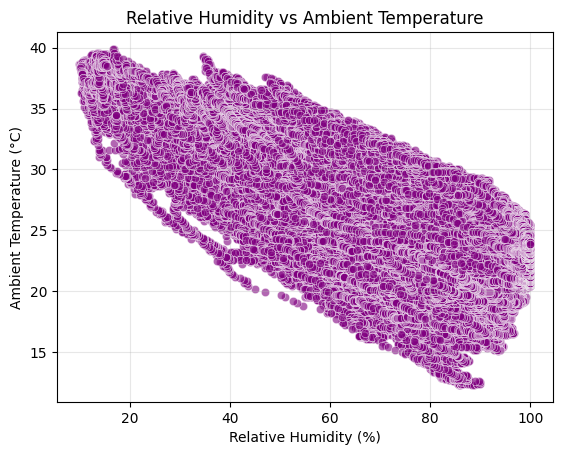

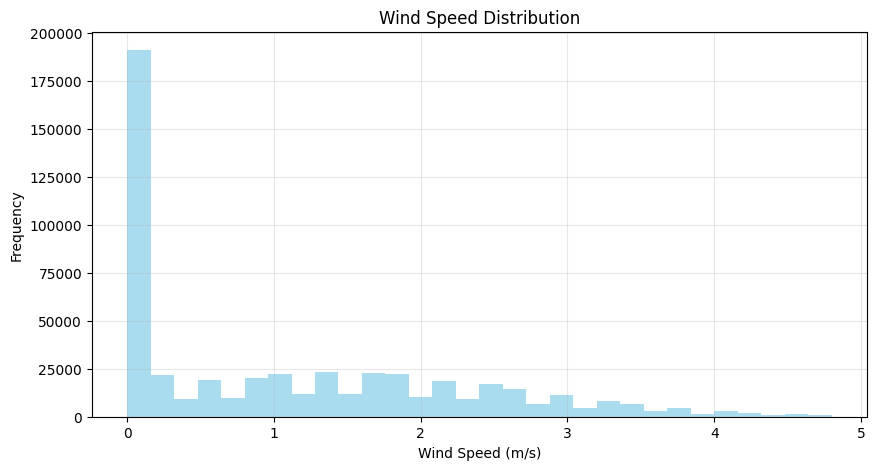

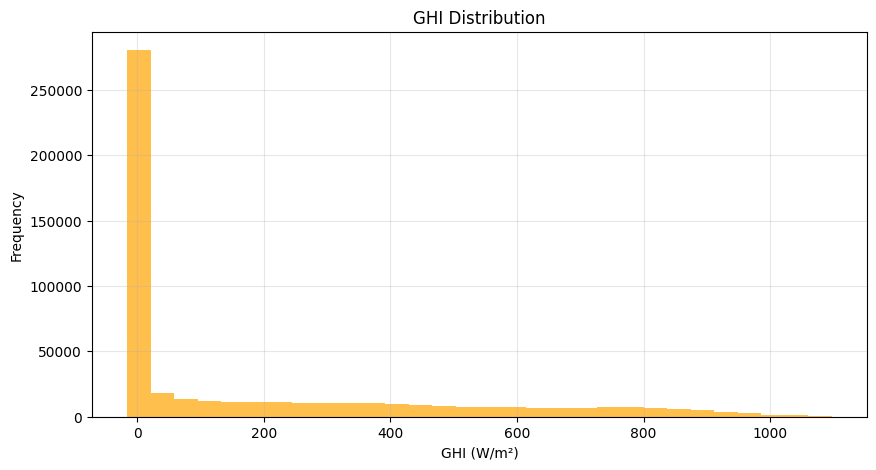

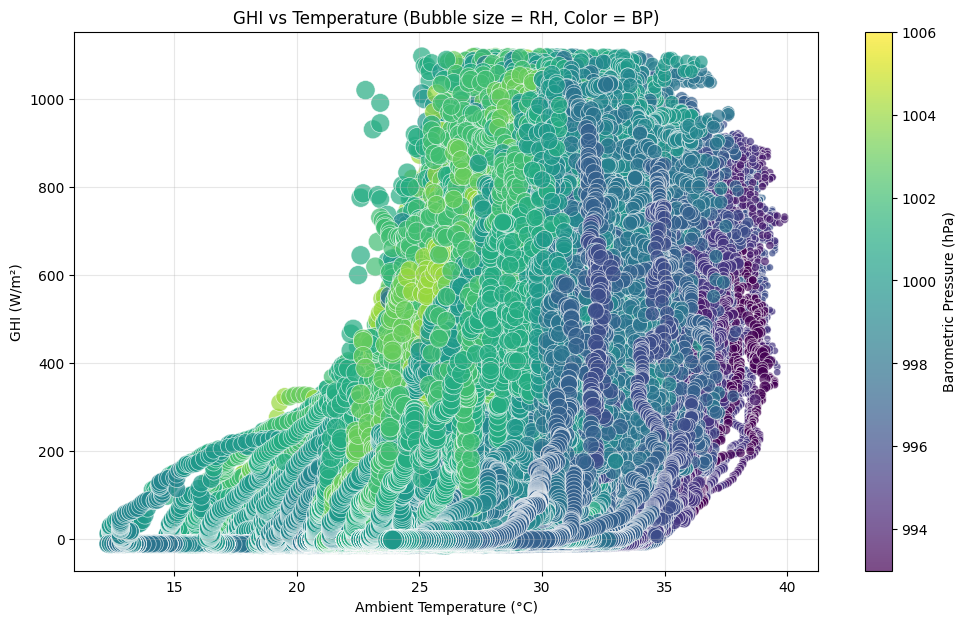

Cleaned dataset saved to ../data/sierraleone_bumbuna_clean.csv


In [1]:
# Sierra Leone Solar Data: EDA & Cleaning
# Import libraries
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load dataset robustly
path = "../data/sierraleone-bumbuna.csv"

if not os.path.exists(path):
    print(f"File not found at {path}")
    print("Current working directory:", os.getcwd())
    print("Top-level files:", os.listdir("."))
    
    if os.path.isdir("../data"):
        print("Files in data/:", os.listdir("../data"))
    
    candidates = glob.glob("**/sierraleone*.csv", recursive=True)
    if candidates:
        print("Found candidate(s):", candidates)
        path = candidates[0]
        print("Using:", path)
    else:
        raise FileNotFoundError(
            f"Could not find 'sierraleone-bumbuna.csv'. Looked at {os.path.abspath('../data')} and recursive search."
        )

df = pd.read_csv(path)
print("CSV loaded successfully!")
df.head()

# 2. Summary Statistics & Missing Values
print("Summary statistics:")
display(df.describe())

print("\nMissing values per column:")
missing_report = df.isna().sum()
display(missing_report[missing_report > 0])

# 3. Outlier Detection & Cleaning
numeric_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)
print(f"Outliers detected: {outlier_mask.sum()} rows")

df_clean = df.copy()
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())
df_clean = df_clean[~outlier_mask]

# 4. Time Series Analysis
df_clean['Timestamp'] = pd.to_datetime(df_clean['Timestamp'])
plt.figure(figsize=(15,5))
plt.plot(df_clean['Timestamp'], df_clean['GHI'], label='GHI', color='orange')
plt.plot(df_clean['Timestamp'], df_clean['DNI'], label='DNI', color='red')
plt.plot(df_clean['Timestamp'], df_clean['DHI'], label='DHI', color='green')
plt.xlabel("Timestamp")
plt.ylabel("Irradiance (W/m²)")
plt.title("Solar Irradiance Over Time - Sierra Leone")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Cleaning Impact
avg_mod_cleaning = df_clean.groupby('Cleaning')[['ModA', 'ModB']].mean()
avg_mod_cleaning.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Module Measurements Pre/Post Cleaning',
    color=['skyblue', 'salmon']
)
plt.ylabel("Average Module Reading (W/m²)")
plt.xlabel("Cleaning Flag (0=Before, 1=After)")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 6. Correlation & Relationships
plt.figure(figsize=(10,8))
sns.heatmap(df_clean[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

sns.scatterplot(
    data=df_clean,
    x='WS',
    y='GHI',
    hue='WSgust',
    palette='coolwarm',
    alpha=0.7,
    edgecolor='k'
)
plt.title("Wind Speed vs GHI (Color = Gust Speed)")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("GHI (W/m²)")
plt.grid(True, alpha=0.3)
plt.legend(title='WS Gust')
plt.show()

sns.scatterplot(data=df_clean, x='RH', y='Tamb', color='purple', alpha=0.6)
plt.title("Relative Humidity vs Ambient Temperature")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Ambient Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()

# 7. Wind & Distribution Analysis
plt.figure(figsize=(10,5))
plt.hist(df_clean['WS'], bins=30, alpha=0.7, color='skyblue')
plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,5))
plt.hist(df_clean['GHI'], bins=30, alpha=0.7, color='orange')
plt.title("GHI Distribution")
plt.xlabel("GHI (W/m²)")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

# 8. Bubble Chart: GHI vs Tamb with RH
plt.figure(figsize=(12,7))
scatter = plt.scatter(
    df_clean['Tamb'],       # x-axis: ambient temperature
    df_clean['GHI'],        # y-axis: GHI
    s=df_clean['RH']*2,     # bubble size proportional to RH
    c=df_clean['BP'],       # color based on barometric pressure
    cmap='viridis',         # color map
    alpha=0.7,
    edgecolors='w',
    linewidth=0.5
)
plt.colorbar(scatter, label='Barometric Pressure (hPa)')
plt.xlabel("Ambient Temperature (°C)")
plt.ylabel("GHI (W/m²)")
plt.title("GHI vs Temperature (Bubble size = RH, Color = BP)")
plt.grid(True, alpha=0.3)
plt.show()

# 9. Export Cleaned Data
output_path = "../data/sierraleone_bumbuna_clean.csv"
df_clean.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to {output_path}")
